In [5]:
### APRENDIZADO POR GRUPO ###
################ Essa é uma das técnicas mais robustas
import pandas as pd #para trabalhar com dados linha x coluna
import numpy as np #tratar dados em forma de vetores , matrizes
from sklearn.model_selection import train_test_split #
from sklearn.ensemble import RandomForestClassifier #biblioteca para criar o modelo
from sklearn.preprocessing import LabelEncoder #biblioteca para codificar dados
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report #biblioteca para avaliar o modelo
import matplotlib.pyplot as plt #biblioteca para plotar gráficos
from sklearn.tree import plot_tree #biblioteca para plotar árvores de decisão

In [6]:
arquivo = pd.read_csv('seguro.csv', keep_default_na=False)
arquivo.head()

,Unnamed: 0,GoodStudent,Idade,SocioEcon,RiskAversion,AnoVeiculo,ThisCarDam,RuggedAuto,Acidente,MakeModel,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,1,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,2,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,3,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,4,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,5,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [7]:
arquivo = arquivo.drop(columns=['Unnamed: 0'])
arquivo.head()

,GoodStudent,Idade,SocioEcon,RiskAversion,AnoVeiculo,ThisCarDam,RuggedAuto,Acidente,MakeModel,DrivQuality,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,Normal,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,Excellent,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,Normal,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [8]:
y = arquivo.iloc[:, 7].values
x = arquivo.drop(arquivo.columns[7], axis=1).values #exclui a coluna indice 7
x

array([[False, 'Adult', 'Prole', ..., False, 'Thousand', 'Many'],
       [False, 'Senior', 'Prole', ..., True, 'Thousand', 'Zero'],
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'One'],
       ...,
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero']],
      dtype=object)

In [9]:
labelencoder = LabelEncoder()
for i in np.arange(x.shape[1]):#percorro todas colunas
  if x[:,i].dtype == 'object': # se a coluna for object
    x[:,i] = labelencoder.fit_transform(x[:,i]) #transformo em numerico

In [10]:
x

array([[0, 1, 1, ..., 0, 3, 0],
       [0, 2, 1, ..., 1, 3, 2],
       [0, 2, 2, ..., 1, 3, 1],
       ...,
       [0, 2, 2, ..., 1, 3, 2],
       [0, 1, 0, ..., 1, 3, 2],
       [0, 1, 0, ..., 1, 3, 2]], dtype=object)

In [11]:
x_treinamento, x_teste, y_treinamento, y_teste = train_test_split(x, y, test_size=0.3, random_state=12)

In [13]:
modelo = RandomForestClassifier(random_state=1, max_depth=20, max_leaf_nodes=12, n_estimators=500) #max_depth número de niveis da arvore (vertical), max_leaf_nodes = número de folhas (horizontal), n_estimators = qnts árvores ele vai induzir
modelo.fit(x_treinamento, y_treinamento)

RandomForestClassifier(max_depth=20, max_leaf_nodes=12, n_estimators=500,
                       random_state=1)

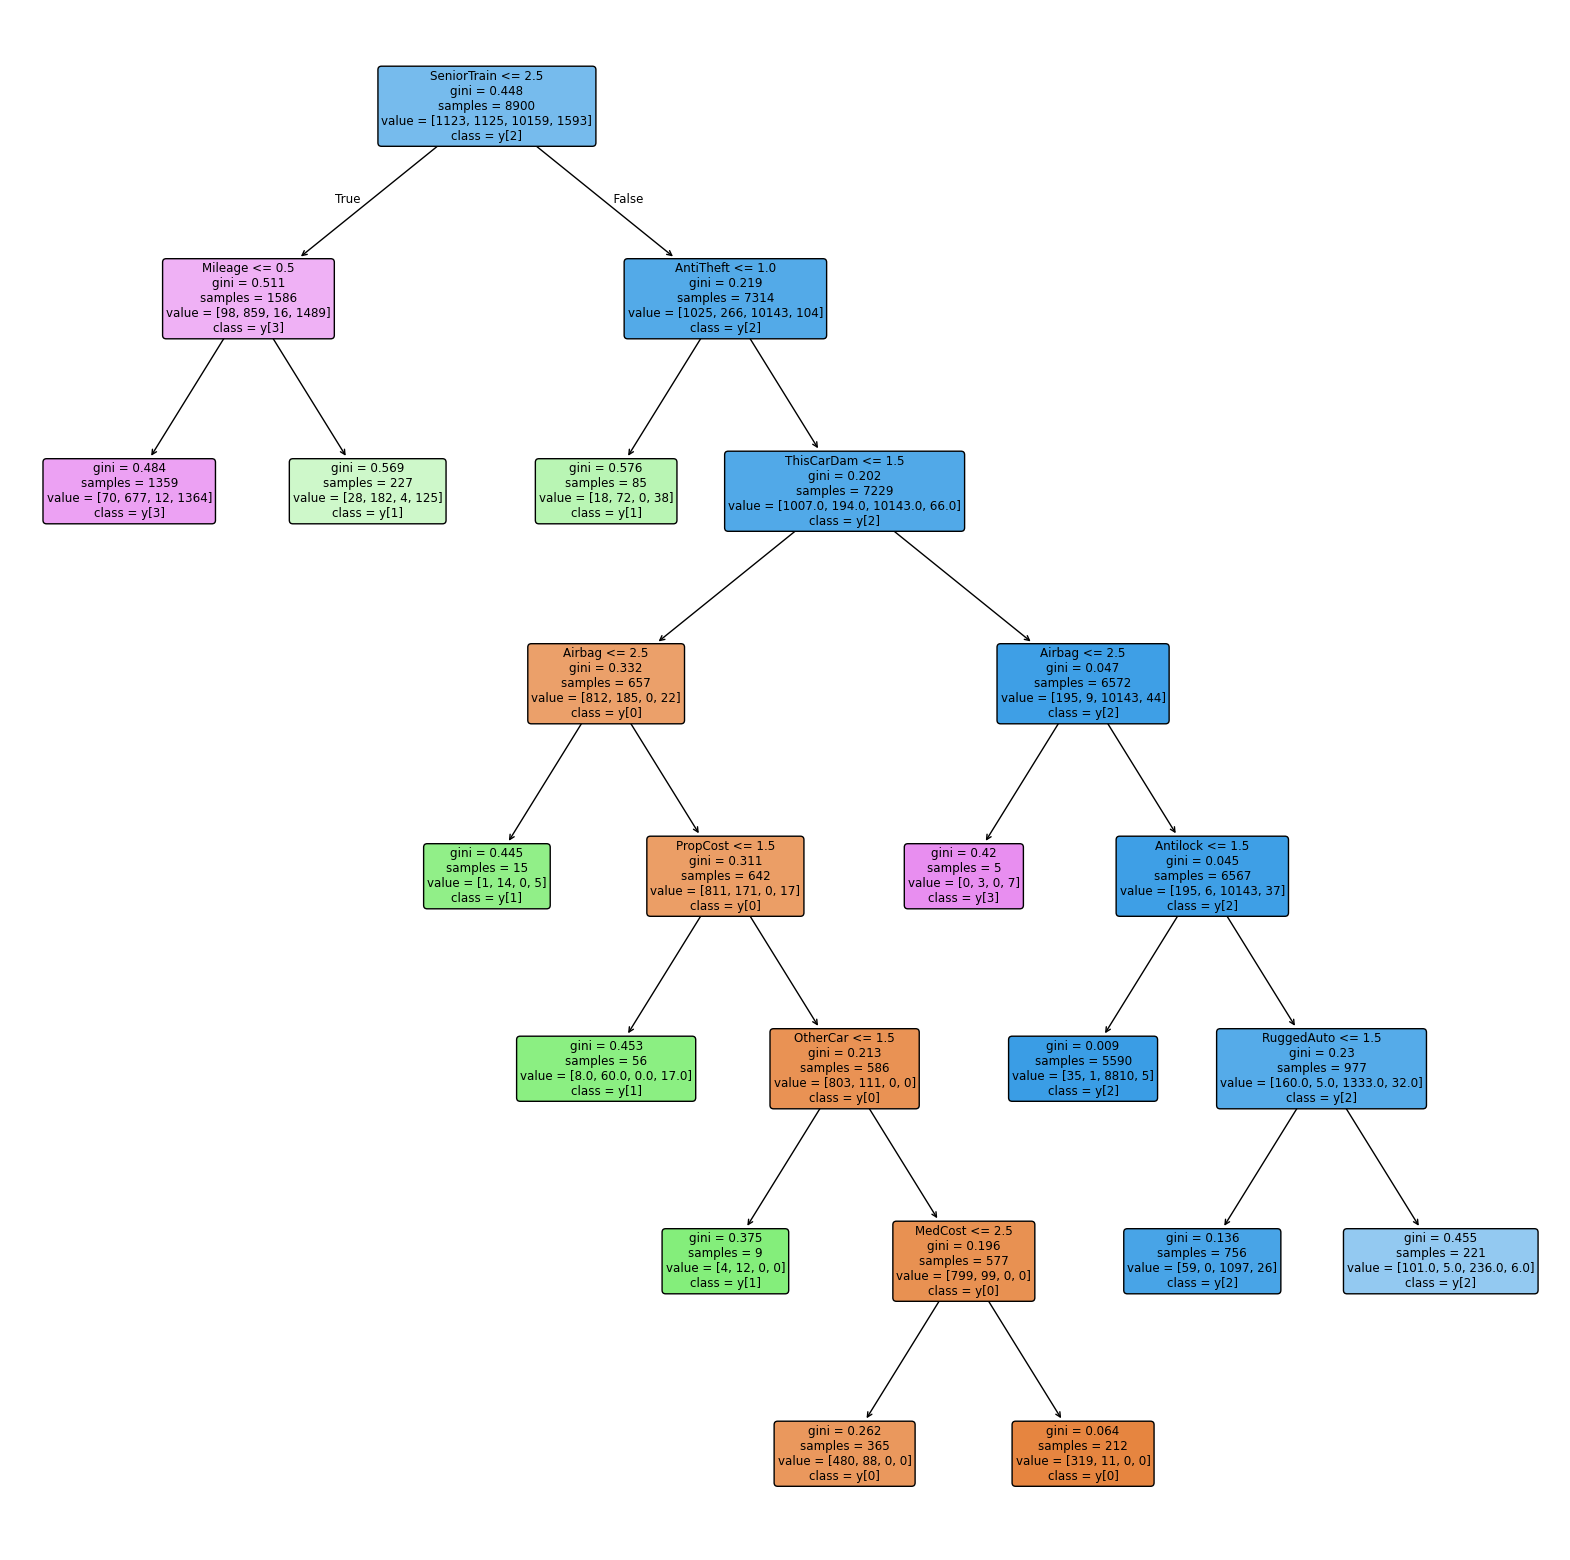

In [20]:
tree_index = 0
tree_to_visualize = modelo.estimators_[tree_index]
plt.figure(figsize=(20, 20))
plot_tree(tree_to_visualize, filled=True, feature_names=arquivo.columns[:-1], class_names=True, rounded=True)
plt.show()

In [21]:
previsoes = modelo.predict(x_teste)
previsoes

array(['Moderate', 'Mild', 'Severe', ..., 'None', 'Mild', 'None'],
      dtype=object)

In [22]:
#produzir métricas:
exatidao = accuracy_score(y_teste, previsoes)
precisao = precision_score(y_teste, previsoes, average='weighted')
revocacao = recall_score(y_teste, previsoes, average='weighted')
f1 = f1_score(y_teste, previsoes, average='weighted')
print(f'Acurácia: {exatidao}, Precisao {precisao}, Recall: {revocacao}, F1: {f1}')

Acurácia: 0.9296666666666666, Precisao 0.9264995089298133, Recall: 0.9296666666666666, F1: 0.9252184168338298


In [23]:
report = classification_report(y_teste, previsoes)
print(report)

              precision    recall  f1-score   support

        Mild       0.88      0.61      0.72       570
    Moderate       0.76      0.69      0.72       488
        None       0.96      1.00      0.98      4253
      Severe       0.87      0.93      0.90       689

    accuracy                           0.93      6000
   macro avg       0.87      0.81      0.83      6000
weighted avg       0.93      0.93      0.93      6000

